# Ehrenfest-LD and FSSH with a PySCF Hamiltonian

Adapted from *"Variety of NA-MD methods in Libra"*. That tutorial drives
`generic_recipe` with analytic model Hamiltonians and offers 25 recipes. This one
keeps the same driver, the same `dyn_general` structure, and the same plotting, and
changes exactly two things:

1. `compute_model` calls **PySCF** instead of evaluating a closed-form model.
2. The recipe menu is **two entries** instead of 25.

## Table of Content: <a name="TOC"></a>

1. [Generic setups](#1)
2. [Theoretical background: the two recipes](#2)
3. [The PySCF Hamiltonian](#3)
4. [Choosing the methodology](#4)
5. [Choosing initial conditions](#5)
6. [Running the calculations](#6)
7. [Plotting the results](#7)
8. [Validation checklist](#8)

## A. Learning objectives

- to replace a model Hamiltonian with an on-the-fly electronic structure call while
  keeping the rest of Libra's dynamics machinery untouched
- to obtain many-body time-overlaps from `gto.intor_cross` across two geometries
- to understand why `ehrenfest_adi_ld` is the natural first recipe for this
  interface, and what `fssh` additionally demands
- to fix MO and state phases, without which the populations are quietly wrong

## B. Why these two recipes

They are chosen to contrast, not because they are the best two methods.

* **`ehrenfest_adi_ld`** needs energies, forces, and time-overlaps. That is exactly
  the set PySCF hands us. Nothing is approximated away to make it fit. Start here.
* **`fssh`** adds stochastic hops, which need a hop-acceptance and
  velocity-rescaling rule. Tully's original rule rescales along the derivative
  coupling vector -- which we do not have. Watching what `fssh` demands is the
  fastest way to internalize what this interface can and cannot deliver.

## C. Environment

**One process.** PySCF's compiled parts (libcint, libxc) link against no MPI and no
Boost, so PySCF imports alongside `liblibra_core` in the conda `libra` env.

    conda activate libra
    python -c "import numpy; print(numpy.__version__)"   # note this number
    pip install --no-deps pyscf
    python -c "import numpy, pyscf, liblibra_core; print('ok')"

`--no-deps` matters: a bare `pip install pyscf` can upgrade numpy underneath conda,
and `liblibra_core` was compiled against the numpy that was there before. If the
last line fails, that is what happened.


### 1.0. Side-loading PySCF from a writable directory

The shared workshop env (`/projects/academic/cyberwksp21/.../envs/libra`) is
read-only, and its kernel launcher does a deliberate hard clean:

```bash
unset PYTHONPATH          # erases anything kernel.json's env block sets
export PYTHONNOUSERSITE=1 # disables ~/.local, so `pip install --user` is invisible
```

So pyscf goes in a directory you own and is added to `sys.path` **from inside the
kernel**, which is downstream of everything the launcher does and cannot be unset.

Install once, from a terminal (absolute path to the env's python, so you get the
right pip without reproducing the module + conda state):

```bash
/projects/academic/cyberwksp21/SOFTWARE/Conda/envs/libra/bin/python -m pip install \
    --no-deps --target=/user/amandal2/libra-extras pyscf
```

`--no-deps` because numpy, scipy, and h5py are already satisfied by the shared env
and must NOT be re-resolved -- `liblibra_core` is compiled against that numpy.

**Note `append`, not `insert(0)`.** This puts `libra-extras` at the END of
`sys.path`, so the shared env wins every name collision and only packages it lacks
(pyscf) resolve here. That makes numpy shadowing structurally impossible rather than
merely unlikely. A `PYTHONPATH` edit could not do this: PYTHONPATH entries always
precede site-packages.

**This cell must run before `import pyscf`.**


In [1]:
import os, sys

EXTRAS = "/user/amandal2/libra-extras"      # where you pip --target'ed pyscf

if not os.path.isdir(EXTRAS):
    raise RuntimeError(f"{EXTRAS} does not exist -- run the pip command above first")
if EXTRAS not in sys.path:
    sys.path.append(EXTRAS)                 # append: shared env wins any collision

import numpy, scipy, pyscf, liblibra_core
for m in (pyscf, numpy, scipy):
    print(f"{m.__name__:8s} {m.__version__:10s} {os.path.dirname(m.__file__)}")
print("liblibra_core: OK")

# Tripwire. With append this should be impossible, but a stray numpy in EXTRAS
# alongside a future sys.path.insert would reintroduce the ABI mismatch silently.
assert EXTRAS not in numpy.__file__, "numpy shadowed by libra-extras -- reinstall with --no-deps"
assert EXTRAS in pyscf.__file__, f"pyscf did NOT come from {EXTRAS} -- check for another copy"


pyscf    2.13.1     /user/amandal2/libra-extras/pyscf
numpy    1.26.4     /projects/academic/cyberwksp21/SOFTWARE/Conda/envs/libra/lib/python3.10/site-packages/numpy
scipy    1.15.2     /projects/academic/cyberwksp21/SOFTWARE/Conda/envs/libra/lib/python3.10/site-packages/scipy
liblibra_core: OK


<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for boost::python::detail::container_element<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, unsigned long, boost::python::detail::final_vector_derived_policies<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, false> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWarning: to-Python converter for std::vector<std::vector<float, std::allocator<float> >, std::allocator<std::vector<float, std::allocator<float> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:241: RuntimeWar

## 1. Generic setups
<a name="1"></a>[Back to TOC](#TOC)

The model tutorial's import block, minus the model Hamiltonians, plus PySCF, and
importing only the two recipes we use.

`from recipes import ...` needs the `recipes/` directory next to this notebook --
copy it from the tutorial directory if it is not there.


In [2]:
import sys
import cmath
import math
import os
import h5py
import matplotlib.pyplot as plt   # plots
import numpy as np
import time
import warnings

from liblibra_core import *
import util.libutil as comn
from libra_py import units
from libra_py import data_conv
from libra_py import dynamics_plotting
import libra_py.dynamics.tsh.compute as tsh_dynamics
import libra_py.dynamics.tsh.plot as tsh_dynamics_plot
import libra_py.data_savers as data_savers

from recipes import ehrenfest_adi_ld
from recipes import fssh

from pyscf import gto, scf, dft, tdscf

warnings.filterwarnings('ignore')

colors = {}
colors.update({"11": "#8b1a0e"})  # red
colors.update({"12": "#FF4500"})  # orangered
colors.update({"13": "#B22222"})  # firebrick
colors.update({"14": "#DC143C"})  # crimson
colors.update({"21": "#5e9c36"})  # green
colors.update({"22": "#006400"})  # darkgreen
colors.update({"23": "#228B22"})  # forestgreen
colors.update({"24": "#808000"})  # olive
colors.update({"31": "#8A2BE2"})  # blueviolet
colors.update({"32": "#00008B"})  # darkblue
colors.update({"41": "#2F4F4F"})  # darkslategray

clrs_index = ["11", "21", "31", "41", "12", "22", "32", "13", "23", "14", "24"]


In [3]:
# Run this first, every time.
import numpy, pyscf
print("python  ", sys.version.split()[0])
print("numpy   ", numpy.__version__)
print("pyscf   ", pyscf.__version__)
print("liblibra_core: OK (it imported alongside pyscf)")


python   3.10.12
numpy    1.26.4
pyscf    2.13.1
liblibra_core: OK (it imported alongside pyscf)


### 2.5. Phases and degeneracies -- why we do NOTHING to the MOs

SCF assigns each MO an arbitrary sign. Worse, inside a **degenerate subspace** it
returns an arbitrary *rotation* -- any unitary mixture of the degenerate orbitals
diagonalizes the Fock matrix equally well, so consecutive steps can hand you
completely different linear combinations. For CO in C-infinity-v, the pi orbitals are
doubly degenerate, and the MO overlap diagonal between two steps is simply
meaningless for those.

The instinct is to fix this. **Do not.** The factorized overlap is invariant under an
orthogonal rotation within the occupied or virtual block. For the virtual block, with
$C' = CU$ and correspondingly $X' = XU$:

$$\sum_b X'^J_{jb} S'^{vv}_{ab}
   = \sum_{b,c,d} X^J_{jc}U_{cb}\,S^{0,vv}_{ad}U_{db}
   = \sum_{c,d} X^J_{jc}S^{0,vv}_{ad}\,\delta_{cd}
   = \sum_c X^J_{jc}S^{0,vv}_{ac}$$

since $UU^T=\mathbb{1}$. Same argument for the occupied block. A sign flip is just a
diagonal $U$, so the sign ambiguity cancels by the same mechanism.

### 2.5.1. What still does need fixing

The **many-body state phases**. Each $|\Psi_I\rangle$ carries an overall sign that
$X$'s normalization does not pin down, and the ground determinant's phase rides on
$\det S^{oo}$. Those are fixed at the state level, after the contraction, by forcing
$\mathrm{diag}(S_{IJ}) > 0$ and carrying the flip into the stored amplitudes so the
next step compares consistently. That is done in `step()` and it is the one phase
operation that survives.

Note this is *ours* to do, not Libra's: `do_phase_correction` acts on Libra's own
`basis_transform` from diagonalizing a diabatic Hamiltonian we never supply
(section 4.3).

### 2.5.2. Choosing `nexc` around degeneracies

Degenerate orbitals mean near-degenerate TDA roots. Do not let `nexc` split a
degenerate pair across the band edge -- you get half a physical multiplet, and
population leaks into a state that is not there. The degeneracy report printed by
`PySCFSource` on its first call is there to let you check.


## 3. The PySCF Hamiltonian
<a name="3"></a>[Back to TOC](#TOC)

This section replaces "3. Model Hamiltonians" in the original tutorial.

Everything PySCF-specific lives in **`pyscf_libra.py`** beside this notebook. Read its
module docstring -- it carries the post-load `dyn_general` overrides and the list of
things that abort the kernel rather than raising.

Two structural differences from a model function are worth naming.

**Adiabatic, not diabatic.** `Holstein.Holstein2` returns `ham_dia`, `d1ham_dia`,
`dc1_dia` and lets Libra diagonalize. There is no diabatic basis here -- PySCF hands
us adiabatic states directly, so we return `ham_adi` / `d1ham_adi` /
`time_overlap_adi` and Libra transforms nothing.

**Stateful.** Model functions are pure: same `q`, same answer. Ours is not -- a
time-overlap needs the previous step's orbitals. With `ntraj > 1` that history is
keyed by trajectory index, or trajectories silently contaminate each other. It also
means `PySCFSource.__deepcopy__` returns `self`, because `generic_recipe` deepcopies
`model_params` on its first line and would otherwise run against a clone.

`PySCFSource` is the only PySCF-aware object in the interface. Swapping in CasidaPy
later is a one-class change; `compute_model` and the dynamics layer never notice.


In [4]:
# The whole PySCF backend lives in pyscf_libra.py, next to this notebook.
# It also handles the sys.path append for a read-only conda env (override with
# the LIBRA_EXTRAS env var), so importing it is all the setup pyscf needs.
#
# Edit the module and rerun this cell to pick up changes:
#   import importlib, pyscf_libra; importlib.reload(pyscf_libra)
from pyscf_libra import (PySCFSource, compute_model, make_model_params,
                         np2cmatrix, q2R, report_degeneracies, tmp, AMU)
import pyscf, numpy, os

print("pyscf_libra loaded")
print("  pyscf ", pyscf.__version__, "from", os.path.dirname(pyscf.__file__))
print("  numpy ", numpy.__version__, "from", os.path.dirname(numpy.__file__))
assert "libra-extras" not in numpy.__file__, "numpy shadowed -- reinstall pyscf with --no-deps"


pyscf_libra loaded
  pyscf  2.13.1 from /user/amandal2/libra-extras/pyscf
  numpy  1.26.4 from /projects/academic/cyberwksp21/SOFTWARE/Conda/envs/libra/lib/python3.10/site-packages/numpy


### 3.1. Define the system

**CO is a plumbing test, not a physics demo.** Its excited states are well
separated, so populations will not do anything dramatic -- which is the point:
anything dramatic here is a bug. Verify the loop end to end, then swap in a system
where the states actually interact.

One caveat for whatever you swap in: linear-response TDDFT describes charge-transfer
and doubly-excited character badly, and gets the S1/S0 conical intersection topology
wrong outright (section 8). Choose a test system whose interesting crossings are
between *excited* states.


In [10]:
#################################
# System definition
#################################
symbols = ["C", "O"]
R0 = np.array([[0.0, 0.0, 0.0],
               [0.0, 0.0, 2.132]])          # Bohr

NEXC = 5                                     # number of excited states
NSTATES = NEXC + 1                           # + ground state

source = PySCFSource(symbols=symbols,
                     basis="6-31G*",
                     xc="pbe0",
                     nexc=NEXC,
                     charge=0, spin=0)

natoms = len(symbols)
NDOF = 3 * natoms

# make_model_params injects the "model"/"model0" keys generic_recipe requires
# but compute_model ignores -- see the module docstring.
model_params = make_model_params(source)

# Smoke test: one call, before committing to thousands.
t0 = time.time()
E, G, St = source.step(R0, traj=0)
dt_call = time.time() - t0
print(f"one step: {dt_call:.2f} s")
print("energies (Ha):        ", np.round(E, 6))
print("excitations (eV):     ", np.round((E[1:] - E[0]) * units.au2ev, 3))
print("grad shape:           ", G.shape)
print("St (first step = identity by construction):\n", np.round(St, 4))


  degenerate MO pairs (expected for symmetric molecules): [(4, 5), (7, 8), (10, 11), (15, 16), (17, 18), (20, 21), (22, 23), (25, 26)]
    [call     1] scf+tda   2.6s  grads   6.9s  |  cumulative    0.2 min  ( 9.5 s/call,  73% in gradients)
one step: 9.49 s
energies (Ha):         [-113.179773 -112.854485 -112.854485 -112.815481 -112.799307 -112.799307]
excitations (eV):      [ 8.851  8.851  9.913 10.353 10.353]
grad shape:            (6, 2, 3)
St (first step = identity by construction):
 [[1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]]


In [11]:
# The real test of the overlap code: a second call at a displaced geometry.
# St should be near-identity but not exactly identity, with a POSITIVE diagonal.
# Large off-diagonals at a small displacement mean phase fixing failed or states
# reordered.
R1 = R0 + np.array([[0.0, 0.0, 0.0], [0.0, 0.0, 0.02]])
E1, G1, St1 = source.step(R1, traj=0)
print("St after 0.02 Bohr displacement:\n", np.round(St1, 4))
print("\ndiagonal:", np.round(np.diag(St1), 4), " <- all should be ~ +1")
print("max |off-diagonal|:", np.round(np.abs(St1 - np.diag(np.diag(St1))).max(), 4))

source.hist.clear()   # reset history before anything real


  note: St diagonal ~0 at states [4 5] -- phase undetermined (expected for degenerate multiplets); left to LD
    [call     2] scf+tda   2.7s  grads   6.7s  |  cumulative    0.3 min  ( 9.4 s/call,  72% in gradients)
St after 0.02 Bohr displacement:
 [[ 0.9955  0.     -0.      0.     -0.005  -0.0042]
 [ 0.      0.9996 -0.0098  0.      0.     -0.    ]
 [-0.      0.0098  0.9996 -0.     -0.      0.    ]
 [ 0.     -0.      0.      0.9998  0.      0.    ]
 [-0.004   0.     -0.     -0.     -0.      0.9998]
 [ 0.0048  0.     -0.      0.     -0.9998 -0.    ]]

diagonal: [ 0.9955  0.9996  0.9996  0.9998 -0.     -0.    ]  <- all should be ~ +1
max |off-diagonal|: 0.9998


### 3.2. Scan the potential energy surfaces

The model tutorial plots 1D surfaces with `dynamics_plotting.plot_surfaces`. That
helper scans a single Libra dof, which for us is a Cartesian component -- not a
chemically meaningful coordinate. So we scan the bond directly instead.

Look at this before running dynamics. If two surfaces never approach, there is no
nonadiabatic physics to find and any population transfer you see is numerical.


  degenerate MO pairs (expected for symmetric molecules): [(4, 5), (7, 8), (10, 11), (14, 15), (17, 18), (20, 21), (22, 23), (24, 25)]
    [call     1] scf+tda   3.4s  grads   0.0s  |  cumulative    0.1 min  ( 3.4 s/call,   0% in gradients)
    [call     2] scf+tda   2.6s  grads   0.0s  |  cumulative    0.1 min  ( 3.0 s/call,   0% in gradients)
    [call     3] scf+tda   2.6s  grads   0.0s  |  cumulative    0.1 min  ( 2.9 s/call,   0% in gradients)
    [call     4] scf+tda   2.6s  grads   0.0s  |  cumulative    0.2 min  ( 2.8 s/call,   0% in gradients)
    [call     5] scf+tda   2.5s  grads   0.0s  |  cumulative    0.2 min  ( 2.8 s/call,   0% in gradients)
    [call     6] scf+tda   2.5s  grads   0.0s  |  cumulative    0.3 min  ( 2.7 s/call,   0% in gradients)
    [call     7] scf+tda   2.6s  grads   0.0s  |  cumulative    0.3 min  ( 2.7 s/call,   0% in gradients)
    [call     8] scf+tda   2.6s  grads   0.0s  |  cumulative    0.4 min  ( 2.7 s/call,   0% in gradients)
  note: St diagon

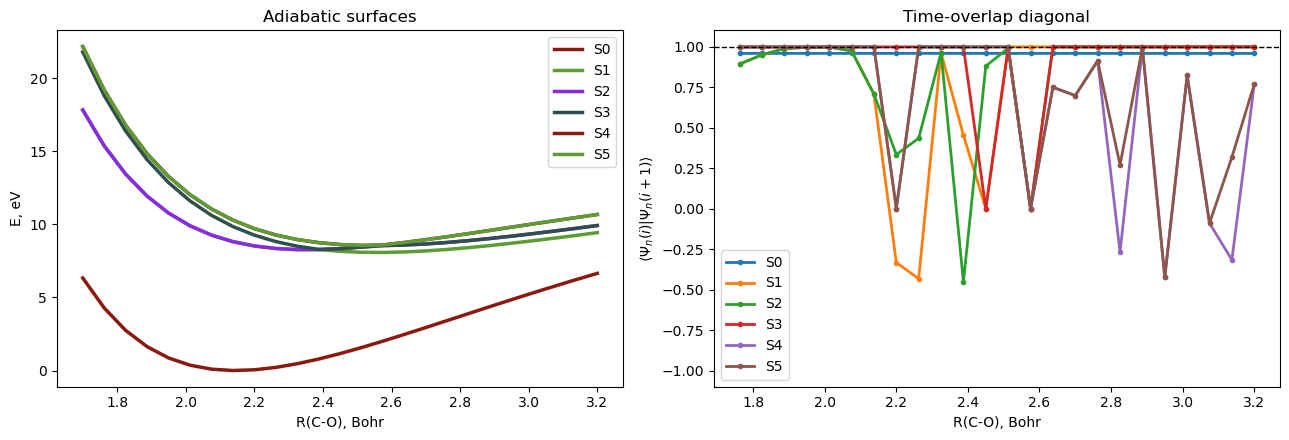

In [12]:
scan = np.linspace(1.7, 3.2, 25)          # Bohr
Es, Sts = [], []
src_scan = PySCFSource(symbols, "6-31G*", "pbe0", NEXC)

t0 = time.time()
for i, r in enumerate(scan):
    R = np.array([[0.0, 0.0, 0.0], [0.0, 0.0, r]])
    e, _, st = src_scan.step(R, traj=0, want_grads=False)   # no grads: much cheaper
    Es.append(e)
    Sts.append(np.diag(st))
Es = np.array(Es)
print(f"scan: {time.time()-t0:.1f} s for {len(scan)} points")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for n in range(NSTATES):
    ax[0].plot(scan, (Es[:, n] - Es[:, 0].min()) * units.au2ev,
               lw=2.5, color="#" + ["8b1a0e", "5e9c36", "8A2BE2", "2F4F4F"][n % 4],
               label=f"S{n}")
ax[0].set_xlabel("R(C-O), Bohr"); ax[0].set_ylabel("E, eV")
ax[0].legend(); ax[0].set_title("Adiabatic surfaces")

# Time-overlap diagonal along the scan. This is a proxy for how well phases and
# state identity are being tracked at a given step size.
Sts = np.array(Sts[1:])
for n in range(NSTATES):
    ax[1].plot(scan[1:], Sts[:, n], lw=2, marker="o", ms=3, label=f"S{n}")
ax[1].axhline(1.0, ls="--", c="k", lw=1)
ax[1].set_xlabel("R(C-O), Bohr"); ax[1].set_ylabel(r"$\langle\Psi_n(i)|\Psi_n(i+1)\rangle$")
ax[1].set_ylim(-1.1, 1.1); ax[1].legend(); ax[1].set_title("Time-overlap diagonal")
plt.tight_layout(); plt.show()


## 4. Choosing the methodology
<a name="4"></a>[Back to TOC](#TOC)

Each recipe file is a menu: one line uncommented per category. They are written for
the tutorial's **2-state model Hamiltonians**, and several of their choices are
actively wrong for an on-the-fly PySCF run. The recipe comments name our workflow
explicitly, so the fixes are not guesswork.

### 4.1. What the recipes set, and what we override

| key | recipe sets | we need | why |
|---|---|---|---|
| `ham_update_method` | 1 (diabatic) | **2** | the file's own comment on 2: *"use with file-based or on-the-fly workflows"* |
| `ham_transform_method` | 1 (diagonalize dia -> adi) | **0** | no diabatic Ham exists to diagonalize. Comment on 0: *"usually for NBRA or on-the-fly workflows, so you don't override the read values"* |
| `time_overlap_method` | 1 (compute from wfc info) | **0** | 1 builds `St` from the diabatic->adiabatic transform. We have no such transform; we supply `time_overlap_adi` ourselves |
| `nac_update_method` | 1 (explicit NACs) | **2** + `nac_algo` | explicit NACs read `dc1_adi`, which is zeros for us |
| `decoherence_rates`, `ave_gaps` | `MATRIX(2,2)` | `MATRIX(NSTATES,NSTATES)` | hard-coded for the 2-state models |
| `hop_acceptance_algo` / `momenta_rescaling_algo` (fssh only) | 20 / 201 (NAC vectors) | **21 / 200** | see 4.4 |

The `MATRIX(2,2)` row is the sneaky one. Every recipe contains

    dyn_general.update({"dephasing_informed":0, "decoherence_rates":MATRIX(2,2),
                        "ave_gaps":MATRIX(2,2)})

sized for a 2-state model. Our CO run has 4 states. With `decoherence_algo:-1` these
are probably never read -- but the moment you switch to `sdm` or `msdm` from the
full tutorial, they are, and a 2x2 where a 4x4 belongs is not the kind of bug that
announces itself.

### 4.2. `nac_algo` -- a knob the tutorial never mentions

`nac_update_method:2` takes a sub-option that appears only in commented-out lines:

    dyn_general.update({"nac_update_method":2, "nac_algo":0})  # HST algo
    dyn_general.update({"nac_update_method":2, "nac_algo":1})  # NPI algo

HST is the Hammes-Schiffer/Tully finite-difference coupling. NPI is norm-preserving
interpolation (Meek & Levine, *J. Phys. Chem. Lett.* **2014**, 5, 2351), which
integrates the coupling analytically across the step instead of finite-differencing
it, and does not blow up when states sweep through a sharp crossing inside one `dt`.

For an on-the-fly run where `dt` is large *because each step costs an SCF*, that is
exactly the failure mode you are exposed to. Default to `nac_algo:1`.

### 4.3. State tracking: do NOT override the LD recipes

`ehrenfest_adi_ld.py` and `ehrenfest_adi_nac.py` differ in exactly two places, and
the diff answers a question that is otherwise pure guesswork:

| | `ehrenfest_adi_ld` | `ehrenfest_adi_nac` |
|---|---|---|
| `electronic_integrator` | 2 (local diabatization) | 5 (2-point Hvib) |
| `state_tracking_algo` | **-1** (off) | 2 (Munkres-Kuhn) |

LD turns state tracking **off on purpose**. The recipe comment says why: tracking and
phase correction do not matter with an LD integrator, because LD consumes the
time-overlap matrix directly -- crossings are handled by `St` itself rather than by
reordering states after the fact. `fssh.py` also uses LD and also sets `-1`.

**But note the scope, because it is easy to draw the wrong conclusion.** Libra's
`state_tracking_algo` and `do_phase_correction` operate on Libra's *own*
`basis_transform`, obtained by diagonalizing a diabatic Hamiltonian. We never give it
one, so those knobs are inert here either way. The phase fixing that actually matters
is upstream, in `PySCFSource`, on the MO coefficients and TDA amplitudes. Libra
cannot do that for us and does not know it needs doing. **Section 2.5 stands
regardless of what these flags say.**

### 4.4. What `fssh` demands that we cannot give

`fssh.py` uncomments:

    dyn_general.update({"hop_acceptance_algo":20, "momenta_rescaling_algo":201 })  # NAC vectors

which is Tully's original prescription and precisely the one setting we cannot
honor -- `dc1_adi` is zeros, so rescaling along it is rescaling along nothing. This
is not a hypothetical: run `fssh` unmodified and it will do something silently
meaningless.

Override to `hop_acceptance_algo:21` with `momenta_rescaling_algo:200/201`, which
rescales along **force differences** -- a quantity we do have. That is not a
workaround; it is the direction Professor Akimov argues for in

> Akimov, A. V. "State Tracking in Nonadiabatic Molecular Dynamics Using Only Forces
> and Energies" *J. Phys. Chem. Lett.* **2024**, 15, 11944-11953.

a method built for exactly the situation of having forces and energies and no
couplings. `hop_acceptance_algo:10` / `101` (total-energy based) is the more
conservative fallback.

None of this touches `ehrenfest_adi_ld` -- `tsh_method:-1`, no hops, nothing to accept.


In [13]:
dyn_general = { "nsteps":200, "ntraj":1, "nstates":NSTATES,
                "dt":10.0, "num_electronic_substeps":20, "isNBRA":0, "is_nbra":0,
                "progress_frequency":0.1,
                "which_adi_states":range(NSTATES), "which_dia_states":range(NSTATES),
                "mem_output_level":3,
                "properties_to_save":[ "timestep", "time", "q", "p", "f", "Cadi",
                "Epot_ave", "Ekin_ave", "Etot_ave", "se_pop_adi", "sh_pop_adi"],
                "prefix":"pyscf_namd", "prefix2":"pyscf_namd"
              }

# NOTE: the workflow overrides do NOT go here -- the recipe's load() runs next and
# would clobber them. They go AFTER load(), in the cell below. See section 4.1.

n_calls = dyn_general["nsteps"] * dyn_general["ntraj"]
print(f"electronic structure calls this run: {n_calls:,}")
print(f"at {dt_call:.1f} s/call, serial: {n_calls * dt_call / 3600:.1f} h")
print(f"trivially parallel over {dyn_general['ntraj']} trajectories -> "
      f"{n_calls * dt_call / 3600 / dyn_general['ntraj']:.1f} h wall on "
      f"{dyn_general['ntraj']} cores")


electronic structure calls this run: 200
at 9.5 s/call, serial: 0.5 h
trivially parallel over 1 trajectories -> 0.5 h wall on 1 cores


In [14]:
#################################
# Give the recipe an index
method_indx = 2
#################################
# 2 - ehrenfest_adi_ld : Ehrenfest, adiabatic rep, local diabatization.
#                        Needs only time-overlaps. Start here.
# 4 - fssh             : Tully's FSSH, no decoherence correction.

if method_indx == 2:
    ehrenfest_adi_ld.load(dyn_general)
elif method_indx == 4:
    fssh.load(dyn_general)
else:
    raise ValueError("this notebook carries two recipes; see the full tutorial "
                     "for the rest, and section 4.1 for which ones are usable")

before = dict(dyn_general)      # snapshot, so we can show what we changed

# ---------------------------------------------------------------------------
# Post-load overrides. The recipes are written for 2-state model Hamiltonians;
# these are the lines that make them correct for on-the-fly PySCF. Section 4.1.
# ---------------------------------------------------------------------------
dyn_general.update({
    "ham_update_method": 2,       # adiabatic properties come FROM the model
    "ham_transform_method": 0,    # no diabatic Ham exists to diagonalize
    "time_overlap_method": 0,     # we supply time_overlap_adi; don't recompute it
    "nac_update_method": 2,       # NACs from time-overlaps, not from dc1_adi
    "nac_algo": 1,                # NPI (Meek-Levine), not HST. Section 4.2.
    "hvib_update_method": 1,      # Hvib from Ham + NACs -- recipe default, correct
})

# Recipes hard-code these at MATRIX(2,2) for the 2-state models. Resize. Section 4.1.
dyn_general.update({"decoherence_rates": MATRIX(NSTATES, NSTATES),
                    "ave_gaps": MATRIX(NSTATES, NSTATES)})

# NOT overridden on purpose: state_tracking_algo. Both LD recipes set -1 deliberately
# and forcing 2 works against the integrator. Section 4.3.

#################################
# Hop acceptance / velocity rescaling (ignored by Ehrenfest: tsh_method is -1)
variant_indx = 4
#################################
suff = ""
if method_indx == 2:
    suff = "na"                                    # no hops, nothing to accept
elif variant_indx == 0:
    dyn_general.update({"hop_acceptance_algo":10, "momenta_rescaling_algo":101})
    suff = "v-"                                    # total-energy based
elif variant_indx == 4:
    dyn_general.update({"hop_acceptance_algo":21, "momenta_rescaling_algo":200})
    suff = "g-"                                    # force-difference based
elif variant_indx == 5:
    dyn_general.update({"hop_acceptance_algo":21, "momenta_rescaling_algo":201})
    suff = "g+"
else:
    raise ValueError("variants 2 and 3 rescale along NAC vectors -- see section 4.4")

param_indx = 0

# Show exactly what we changed relative to the recipe. Read this output.
print("recipe:", {2:"ehrenfest_adi_ld", 4:"fssh"}[method_indx], "| variant:", suff)
print("\noverrides applied on top of the recipe:")
for k in sorted(set(before) | set(dyn_general)):
    b, a = before.get(k, "<unset>"), dyn_general.get(k, "<unset>")
    if isinstance(b, MATRIX) or isinstance(a, MATRIX):
        continue
    if b != a:
        print(f"  {k:28s} {str(b):>6s}  ->  {a}")
print("  decoherence_rates, ave_gaps  MATRIX(2,2)  ->  MATRIX"
      f"({NSTATES},{NSTATES})")

# Guard: fssh's NAC-vector rescaling is meaningless with dc1_adi = 0.
if dyn_general.get("hop_acceptance_algo") == 20:
    raise RuntimeError("hop_acceptance_algo:20 rescales along NAC vectors, which "
                       "are zeros here -- see section 4.4")


recipe: ehrenfest_adi_ld | variant: na

overrides applied on top of the recipe:
  ham_transform_method              1  ->  0
  ham_update_method                 1  ->  2
  nac_algo                     <unset>  ->  1
  nac_update_method                 1  ->  2
  time_overlap_method               1  ->  0
  decoherence_rates, ave_gaps  MATRIX(2,2)  ->  MATRIX(6,6)


## 5. Choosing initial conditions
<a name="5"></a>[Back to TOC](#TOC)

Same `nucl_params` / `elec_params` structure as the model tutorial. `ndof` is now
`3 * natoms` and the masses are real.

**On sampling.** The tutorial uses `init_type:3` with a per-dof `force_constant`,
sampling from the ground state of a harmonic well of that stiffness. For a molecule
the defensible version is a **Wigner distribution over normal modes**: Hessian,
project out translations and rotations, sample each mode.

The cell below approximates that with per-dof force constants from the Hessian
diagonal. That is fine for a smoke test and **not** fine for production: it ignores
mode mixing and does not project out translation or rotation, so the molecule will
drift and tumble carrying spurious energy. Replace it with proper normal-mode Wigner
sampling before believing any populations.


In [18]:
# Proper normal-mode Wigner (v=0, ħ=1 a.u.). Replaces Hessian-diagonal shortcut.
rng = np.random.default_rng(0)   # fix seed for reproducibility

mol0 = source._mol(R0)
mf0 = dft.RKS(mol0, xc=source.xc)
mf0.grids.level = source.grid_level
mf0.kernel()
hess = mf0.Hessian().kernel()                 # (natoms, natoms, 3, 3)

masses = np.asarray(source.masses_au(R0), dtype=float)
H = hess.transpose(0, 2, 1, 3).reshape(NDOF, NDOF)   # Cartesian Hessian
D = H / np.sqrt(np.outer(masses, masses))             # mass-weighted

evals, evecs = np.linalg.eigh(D)                      # ω², L
# Linear molecule: drop 5 near-zero modes (3 trans + 2 rot). Nonlinear: 6.
n_zero = 5 if natoms == 2 else 6
order = np.argsort(evals)
vib = order[n_zero:]
omega2 = evals[vib]
omega = np.sqrt(np.maximum(omega2, 0.0))
L = evecs[:, vib]                                     # columns = mass-weighted modes

# Reject soft/imaginary leftovers from a non-minimum geometry
keep = omega > 1e-4
omega, L = omega[keep], L[:, keep]
if omega.size == 0:
    raise RuntimeError("No real vibrational modes — optimize R0 first")

# Ground-state Wigner in normal-mode coords:
#   Q_i ~ N(0, 1/sqrt(ω_i)),  P_i ~ N(0, sqrt(ω_i))
Q = rng.normal(0.0, 1.0 / np.sqrt(omega))
P = rng.normal(0.0, np.sqrt(omega))

inv_sqrt_m = 1.0 / np.sqrt(masses)
sqrt_m = np.sqrt(masses)
q = R0.flatten() + inv_sqrt_m * (L @ Q)               # Cartesian positions
p = sqrt_m * (L @ P)                                  # Cartesian momenta

icond_nucl = 0   # DO NOT let Libra resample Cartesians
nucl_params = {"ndof": NDOF,
               "q": [float(x) for x in q],
               "p": [float(x) for x in p],
               "mass": [float(m) for m in masses],
               "force_constant": [1.0] * NDOF,         # unused with init_type=0
               "init_type": icond_nucl}

# --- electronic ICs unchanged ---
icond_elec = 3
rep = 1
istates = [0.0] * NSTATES
istates[1] = 1.0
elec_params = {"verbosity": 2, "init_dm_type": 0,
               "ndia": NSTATES, "nadi": NSTATES,
               "rep": rep, "init_type": icond_elec, "istates": istates}

icond_type_indx = rep * 8 + (icond_elec - 2) * 4 + icond_nucl
icond_indx = 0

print("ω (a.u.):", np.round(omega, 6))
print("ω (cm^-1):", np.round(omega * 219474.63, 1))   # Ha → cm^-1
print("|COM momentum|:", np.linalg.norm(p.reshape(-1, 3).sum(0)))

ω (a.u.): [0.010463]
ω (cm^-1): [2296.4]
|COM momentum|: 4.864730337450496e-06


## 6. Running the calculations
<a name="6"></a>[Back to TOC](#TOC)

Identical call to the model tutorial. Everything PySCF is behind `compute_model`.


In [19]:
%%time

source.hist.clear()
source.ncalls = 0

dyn_params = dict(dyn_general)
pref = (f"pyscf-method{method_indx}-variant_{suff}-param{param_indx}"
        f"-icond_type{icond_type_indx}-icond{icond_indx}")
dyn_params.update({"prefix":pref, "prefix2":pref})

print(f"Computing {pref}")

rnd = Random()
res = tsh_dynamics.generic_recipe(dyn_params, compute_model, model_params,
                                  elec_params, nucl_params, rnd)

print(f"\nelectronic structure calls: {source.ncalls:,}")


Computing pyscf-method2-variant_na-param0-icond_type12-icond0
Active states (adiabatic)
[1]
Initial adiabatic populations
[0.0, 1.0, 0.0, 0.0, 0.0, 0.0]
ined! in the input parametersUse the default value 
In cctor: lvl = 1 der_lvl = 2
======= Initialization type is 3 ========
setting representation 1 coefficients C_i for all i to complex numbers such that |C_i|^2  = target populations 
========== ampl_dia ===============
(0.0000000,0.0000000)  
(0.0000000,0.0000000)  
(0.0000000,0.0000000)  
(0.0000000,0.0000000)  
(0.0000000,0.0000000)  
(0.0000000,0.0000000)  

========== ampl_adi ===============
(0.0000000,-0.0000000)  
(-0.36265591,-0.93192311)  
(0.0000000,-0.0000000)  
(-0.0000000,-0.0000000)  
(-0.0000000,0.0000000)  
(-0.0000000,-0.0000000)  

========== states ===============
======= Initialization type is 0 ========
setting DM in representation 1 using wfc amplitudes 
WARNINIG in init_auxiliary_variables:           the init_type = 3 is not known. Allowed values are: [0]


 step= 0
    [call     2] scf+tda   2.5s  grads   5.2s  |  cumulative   37.7 min  (1131.8 s/call,  73% in gradients)
    [call     3] scf+tda   2.0s  grads   6.0s  |  cumulative   37.9 min  (757.2 s/call,  73% in gradients)
    [call     4] scf+tda   2.2s  grads   6.7s  |  cumulative   38.0 min  (570.1 s/call,  73% in gradients)
    [call     5] scf+tda   2.6s  grads   6.9s  |  cumulative   38.2 min  (458.0 s/call,  73% in gradients)
    [call     6] scf+tda   2.3s  grads   5.3s  |  cumulative   38.3 min  (382.9 s/call,  73% in gradients)
    [call     7] scf+tda   2.2s  grads   5.9s  |  cumulative   38.4 min  (329.4 s/call,  73% in gradients)
    [call     8] scf+tda   2.3s  grads   6.8s  |  cumulative   38.6 min  (289.3 s/call,  73% in gradients)
    [call     9] scf+tda   2.6s  grads   6.8s  |  cumulative   38.7 min  (258.2 s/call,  73% in gradients)
    [call    10] scf+tda   2.4s  grads   5.2s  |  cumulative   38.9 min  (233.2 s/call,  73% in gradients)
    [call    11] scf+tda   

    [call    78] scf+tda   2.8s  grads   6.1s  |  cumulative   49.2 min  (37.8 s/call,  72% in gradients)
    [call    79] scf+tda   2.8s  grads   6.2s  |  cumulative   49.3 min  (37.5 s/call,  72% in gradients)
    [call    80] scf+tda   2.7s  grads   6.2s  |  cumulative   49.5 min  (37.1 s/call,  72% in gradients)
    [call    81] scf+tda   2.8s  grads   6.1s  |  cumulative   49.6 min  (36.7 s/call,  72% in gradients)
 step= 80
    [call    82] scf+tda   2.8s  grads   6.9s  |  cumulative   49.8 min  (36.4 s/call,  72% in gradients)
    [call    83] scf+tda   3.1s  grads   6.1s  |  cumulative   49.9 min  (36.1 s/call,  72% in gradients)
    [call    84] scf+tda   2.5s  grads   6.1s  |  cumulative   50.1 min  (35.8 s/call,  72% in gradients)
    [call    85] scf+tda   2.7s  grads   6.9s  |  cumulative   50.2 min  (35.5 s/call,  72% in gradients)
    [call    86] scf+tda   3.1s  grads   6.7s  |  cumulative   50.4 min  (35.2 s/call,  72% in gradients)
    [call    87] scf+tda   2.4s  gra

    [call   155] scf+tda   3.2s  grads   6.9s  |  cumulative   60.6 min  (23.5 s/call,  72% in gradients)
    [call   156] scf+tda   2.8s  grads   5.6s  |  cumulative   60.8 min  (23.4 s/call,  72% in gradients)
    [call   157] scf+tda   2.7s  grads   6.3s  |  cumulative   60.9 min  (23.3 s/call,  72% in gradients)
    [call   158] scf+tda   3.2s  grads   7.0s  |  cumulative   61.1 min  (23.2 s/call,  72% in gradients)
    [call   159] scf+tda   3.2s  grads   5.7s  |  cumulative   61.2 min  (23.1 s/call,  72% in gradients)
    [call   160] scf+tda   2.6s  grads   6.1s  |  cumulative   61.4 min  (23.0 s/call,  72% in gradients)
    [call   161] scf+tda   2.8s  grads   6.9s  |  cumulative   61.5 min  (22.9 s/call,  72% in gradients)
 step= 160
    [call   162] scf+tda   3.2s  grads   6.9s  |  cumulative   61.7 min  (22.9 s/call,  72% in gradients)
    [call   163] scf+tda   2.8s  grads   5.3s  |  cumulative   61.8 min  (22.8 s/call,  72% in gradients)
    [call   164] scf+tda   2.7s  gr

### 6.1. Scaling: more processes, not a bigger `ntraj`

`ntraj=8` in one notebook is eight trajectories computed one after another. Nothing
is shared between them except the SCF guess (which is per-trajectory anyway), so
serializing them buys you nothing at all.

Trajectories are independent. Run `ntraj=1` per process with a different RNG seed
and combine the HDF5 outputs afterwards -- 8 array tasks on 8 cores finish in the
time one trajectory takes.

Where the time actually goes, and what to do about it:

| lever | effect | cost |
|---|---|---|
| `ntraj=1` x N array jobs | ~N x speedup | none -- do this |
| smaller basis (3-21G) for plumbing tests | large | wrong numbers; fine for debugging |
| fewer states (`NEXC`) | each dropped state removes one TDA gradient | but do not split a degenerate multiplet (2.5.2) |
| `grid_level = 2` | modest | gradient noise -> energy drift. Check conservation |
| `conv_tol = 1e-8` | small | fine |
| `dt` larger | fewer steps | `nac_algo:1` (NPI) is what makes this survivable |

Do not reach for `force_method:1` (FSSH) expecting a saving. Libra picks the active
state's gradient out of `d1ham_adi`, so `compute_model` still has to compute all of
them -- the interface gives us no way to know the active state in advance.


## 7. Plotting the results
<a name="7"></a>[Back to TOC](#TOC)

For `ehrenfest_adi_ld` the meaningful populations are `se_pop_adi` -- the
wavefunction amplitudes. There is no active state, so `sh_pop_adi` is not
informative. For `fssh` both are meaningful, and their disagreement is the standard
diagnostic for overcoherence.


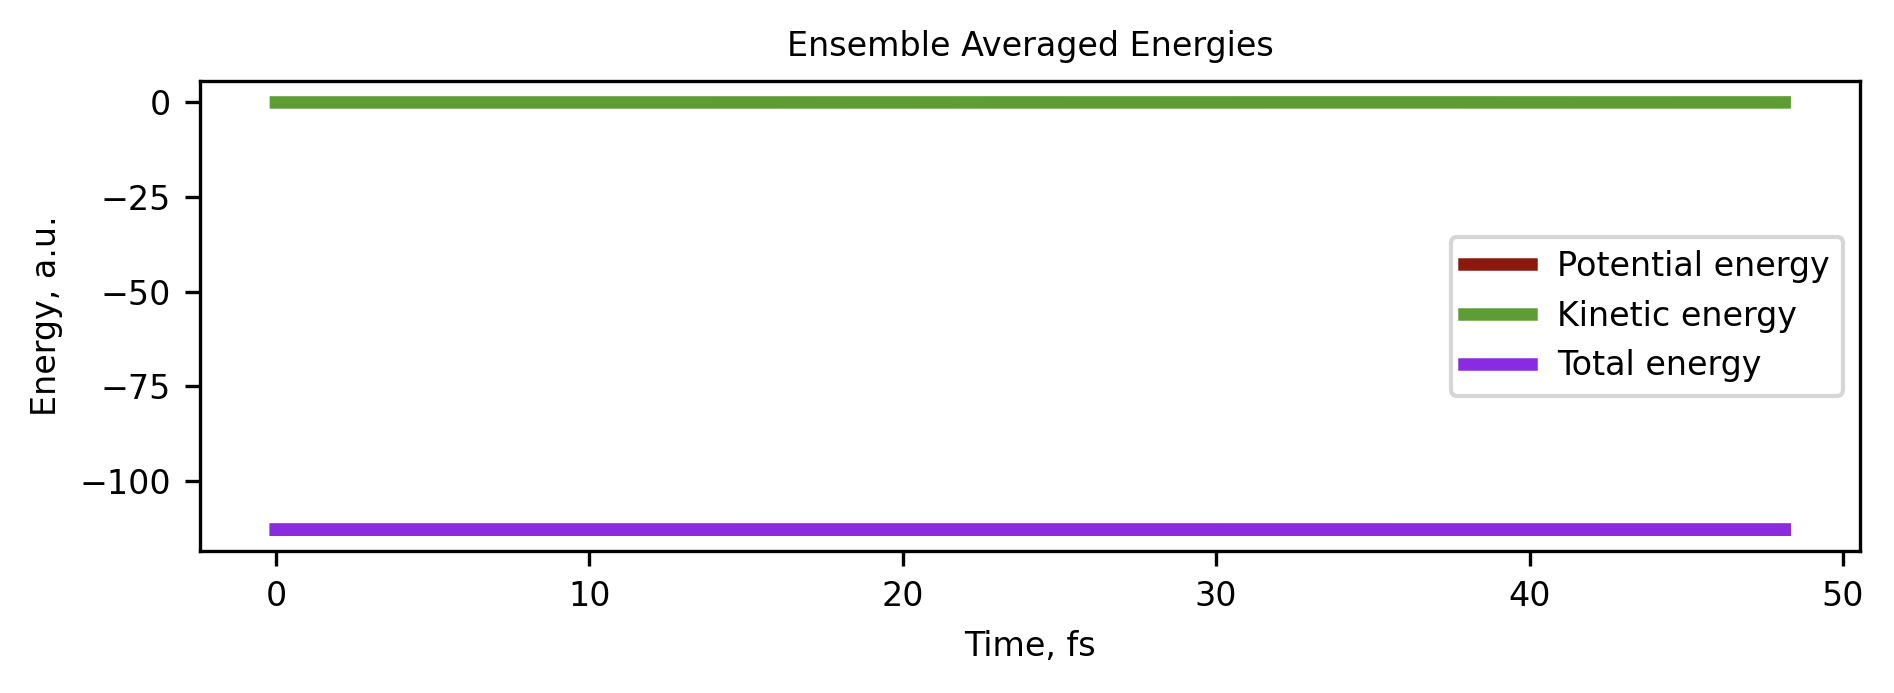

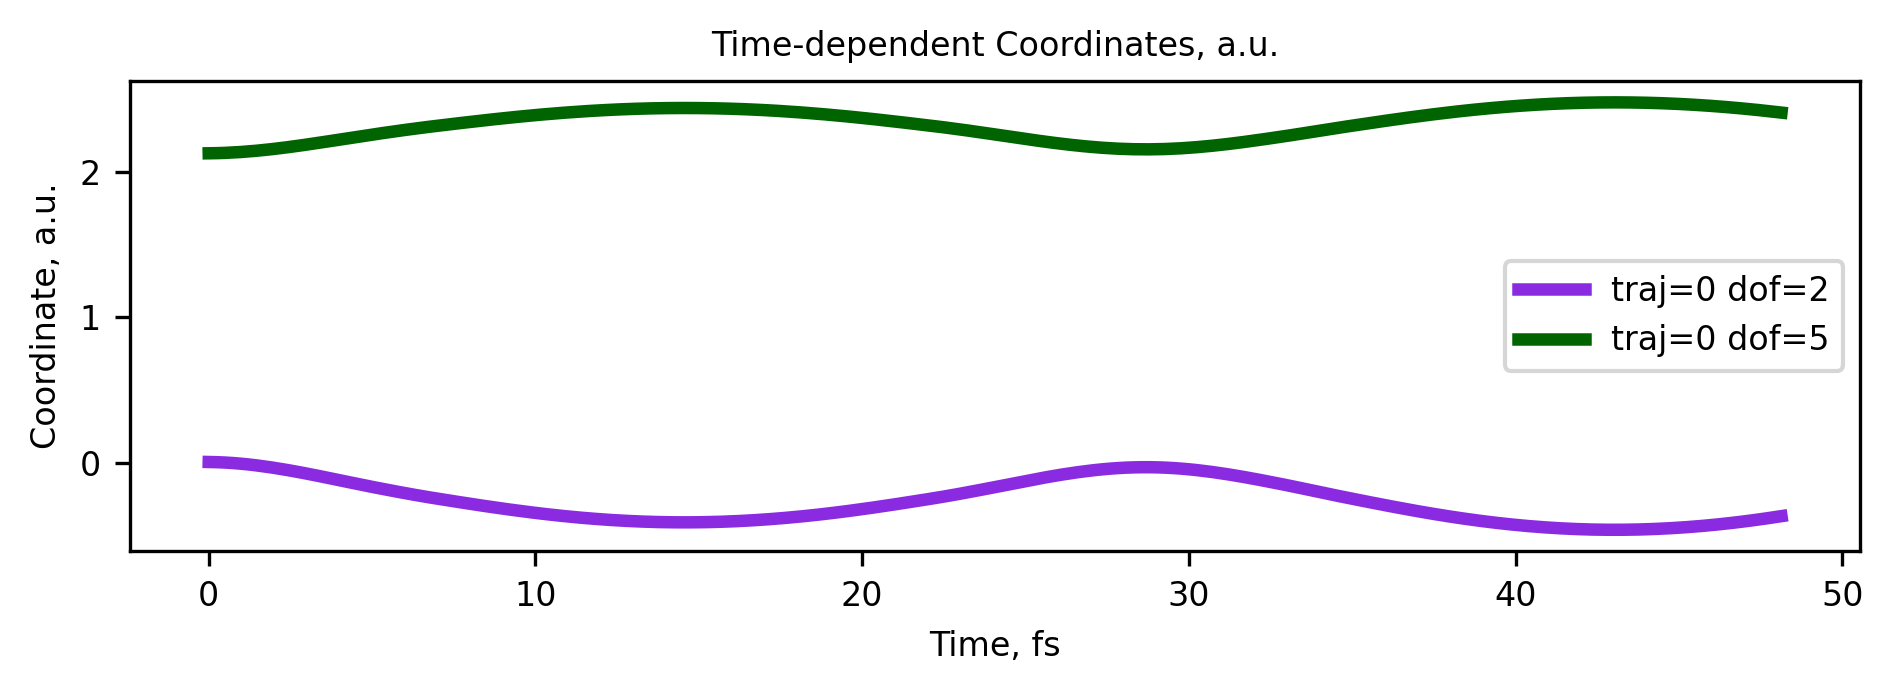

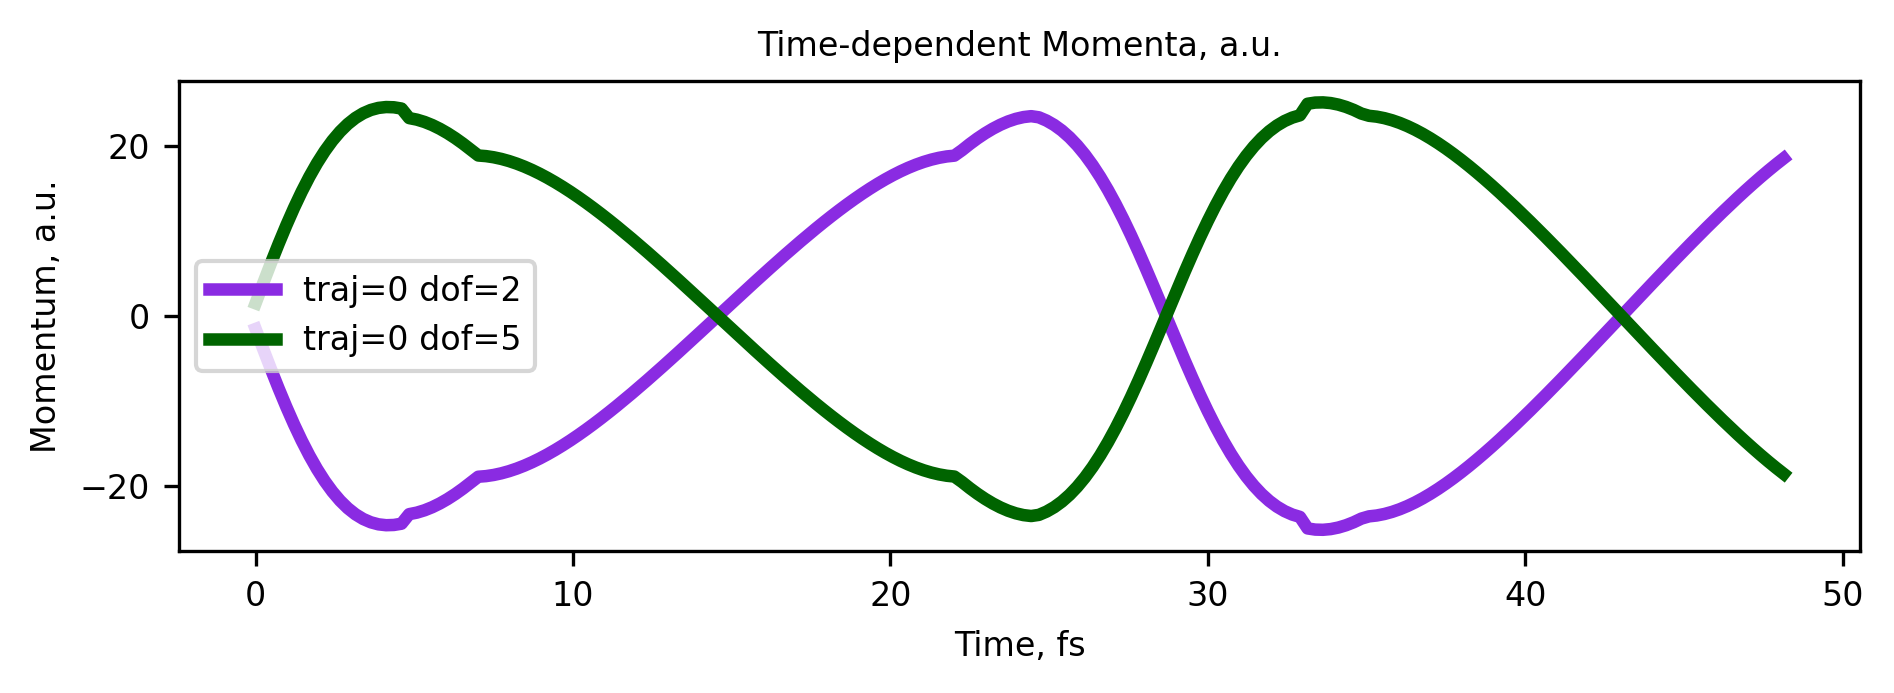

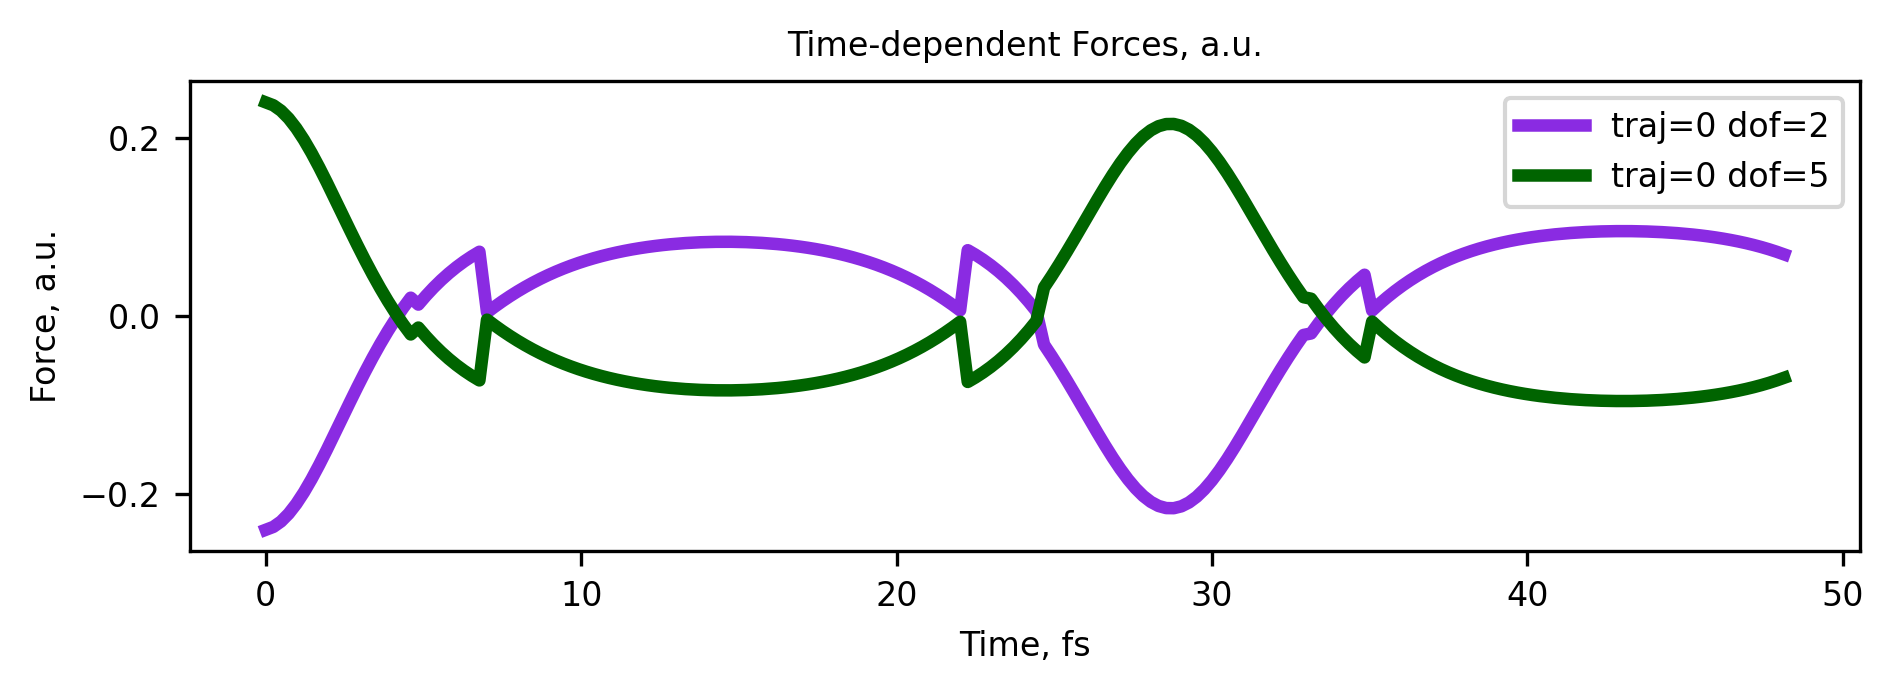

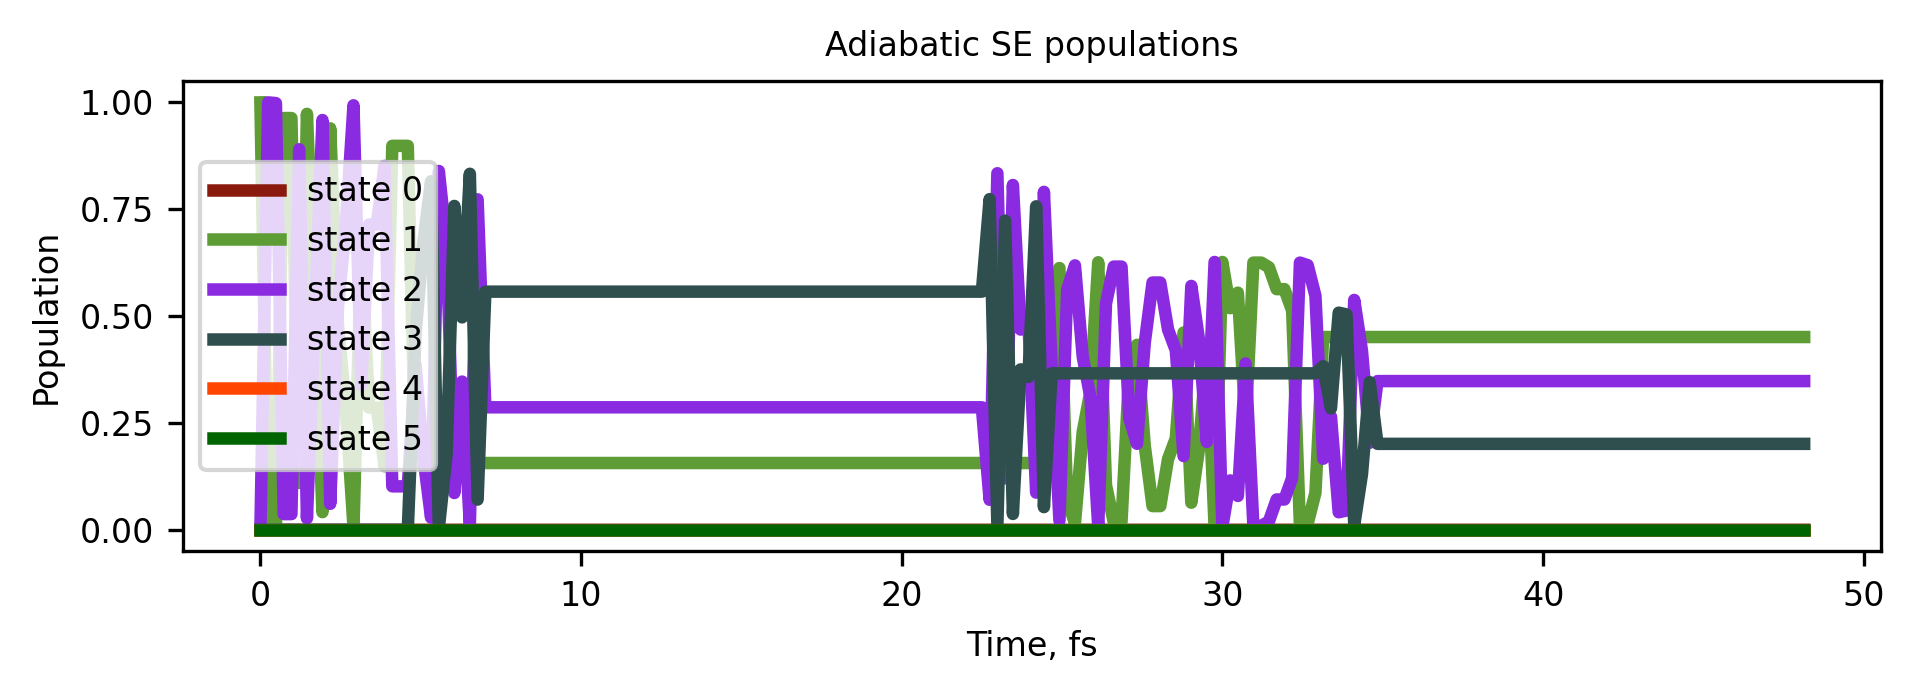

In [20]:
what = ["coordinates", "momenta", "forces", "energies", "se_pop_adi"]
if method_indx == 4:
    what.append("sh_pop_adi")

plot_params = { "prefix":pref, "filename":"mem_data.hdf", "output_level":3,
                "which_trajectories":[0, 1, 2], "which_dofs":[2, 5],
                "which_adi_states":list(range(NSTATES)),
                "which_dia_states":list(range(NSTATES)),
                "frameon":True, "linewidth":3, "dpi":300,
                "axes_label_fontsize":(8,8), "legend_fontsize":8,
                "axes_fontsize":(8,8), "title_fontsize":8,
                "what_to_plot":what,
                "which_energies":["potential", "kinetic", "total"],
                "save_figures":1, "do_show":1
              }

tsh_dynamics_plot.plot_dynamics(plot_params)


## 8. Validation checklist
<a name="8"></a>[Back to TOC](#TOC)

Work down this before believing anything. Every item has burned someone.

**1. Total energy conservation.** Plot it first. Drift means `dt` is too large, the
SCF is too loose (`conv_tol`), or the DFT grid is too coarse. Grid noise in
gradients is a classic slow-drift source -- try `grid_level = 5` before blaming the
integrator.

**2. Time-overlap diagonal near +1.** Section 3.2 plots this along a scan; do the
same along a trajectory. Values near -1 mean phase fixing failed. Values near 0 mean
states reordered faster than `dt` can follow -- shorten `dt`, and note that `nac_algo:1`
(NPI) is specifically what makes a large `dt` survivable here.

**2b. `time_overlap_method:0` is doing something.** This is the one setting the
recipes could not confirm for us. If populations never move, or `St` is silently the
identity every step, Libra is not reading `time_overlap_adi` off the model object --
run the grep in section 2.6 and set it on the Hamiltonian directly instead.

**3. Gradient sign.** `d1ham_adi` is dH/dR. `nuc_grad_method` returns dE/dR. Same
sign, no negation. If the molecule explodes on step one, this is why.

**4. Wigner sampling.** The Hessian-diagonal shortcut in section 5 is a placeholder.
Replace it before production.

**5. Ehrenfest before FSSH.** `ehrenfest_adi_ld` exercises the whole interface with
no hopping machinery on top. If it does not conserve energy, FSSH results are
meaningless -- the problem is upstream of the method.

**6. Bare FSSH overcoheres.** `fssh.py` sets `decoherence_algo:-1`. `se_pop_adi` and
`sh_pop_adi` diverging is the signature. That is a known property of the method, not a
bug here -- add `ida`, `sdm`, or `bcsh` from the full tutorial once the plumbing is
verified. When you do: those recipes read `decoherence_rates` / `ave_gaps`, which ship
hard-coded at `MATRIX(2,2)`. The override cell resizes them; keep it.

**7. TDA vs full TDDFT.** This notebook uses TDA deliberately. Full TDDFT can return
imaginary excitation energies near S1/S0 crossings, and linear response gets the
S1/S0 conical intersection topology wrong regardless -- the branching space has the
wrong dimensionality. If trajectories reach S1/S0, no dynamics machinery repairs
that; you need spin-flip TDDFT or a multireference method. If the crossings that
matter are between excited states, linear response is fine.

**8. Cost.** `nsteps x ntraj` calls, each an SCF plus TDDFT plus `nstates`
gradients. This is the bottleneck, not the interface. Embarrassingly parallel over
trajectories -- scale by running trajectories on separate cores, not by
parallelizing PySCF.

### Next steps

- **Rigorous overlaps.** Swap the factorized formula in `_state_overlaps` for
  `libra_py.workflows.nbra.mapping.ovlp_arb` over a proper SD basis.
- **More recipes.** `ida`, `sdm`, `bcsh`, `fssh2`, `mash` all drop in -- they need
  only what `fssh` needs. Copy the `elif` branches from the full tutorial and keep the
  post-load override cell as-is; it is recipe-agnostic. Check each one's
  `hop_acceptance_algo` first -- `bcsh.py` also hard-codes 20/201.
- **CasidaPy.** `PySCFSource` is the only PySCF-aware object here. Swapping it out
  is a one-class change, which is the main reason to keep that boundary clean.
